# BEAD Random Forest — Total Project Funding
Predicts **total project funding** (`bead_support`) directly, rather than per-location funding.

Log-transformed target: `log1p(bead_support)`

Key difference from per-location model: `funded_locations` is included as a feature
(no longer leaky since it's not part of the target calculation).

Includes ablation study, SHAP, and LIME interpretability analysis.

In [1]:
from google.cloud import bigquery
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

client = bigquery.Client(project='broadband-data')
print('Connected to BigQuery: broadband-data')

Connected to BigQuery: broadband-data


In [2]:
# Load all data sources
df_projects = client.query("""
SELECT project_id, state, bead_support, estimated_miles_aerial_fiber,
       estimated_miles_buried_fiber, estimated_jobs, project_type, priority_broadband_project
FROM `broadband-data.fp_approved.deployment_projects`
""").to_dataframe()

df_locations = client.query("""
SELECT project_id, COUNT(*) AS funded_locations,
       SAFE_CAST(APPROX_TOP_COUNT(CAST(technology AS STRING), 1)[OFFSET(0)].value AS FLOAT64) AS technology,
       AVG(CAST(low_latency AS INT64)) AS avg_latency
FROM `broadband-data.fp_approved.locations`
GROUP BY project_id
""").to_dataframe()

state_name_to_abbr = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR', 'California': 'CA',
    'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE', 'Florida': 'FL', 'Georgia': 'GA',
    'Hawaii': 'HI', 'Idaho': 'ID', 'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA',
    'Kansas': 'KS', 'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD',
    'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS',
    'Missouri': 'MO', 'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV', 'New_Hampshire': 'NH',
    'New_Jersey': 'NJ', 'New_Mexico': 'NM', 'New_York': 'NY', 'North_Carolina': 'NC',
    'North_Dakota': 'ND', 'Ohio': 'OH', 'Oklahoma': 'OK', 'Oregon': 'OR', 'Pennsylvania': 'PA',
    'Rhode_Island': 'RI', 'South_Carolina': 'SC', 'South_Dakota': 'SD', 'Tennessee': 'TN',
    'Texas': 'TX', 'Utah': 'UT', 'Vermont': 'VT', 'Virginia': 'VA', 'Washington': 'WA',
    'West_Virginia': 'WV', 'Wisconsin': 'WI', 'Wyoming': 'WY', 'District_of_Columbia': 'DC'
}
df_nbm = client.query("""
SELECT state, COUNT(DISTINCT frn) AS state_num_providers
FROM `broadband-data.fcc_nbm.nbm_hive` GROUP BY state
""").to_dataframe()
df_nbm['state'] = df_nbm['state'].map(state_name_to_abbr)
df_nbm = df_nbm.dropna(subset=['state'])

df_state_pop = client.query("""
SELECT stateabbr AS state, SUM(pop2020) AS state_population
FROM `broadband-data.fcc_block_level_pop.us2020` GROUP BY stateabbr
""").to_dataframe()

print(f'Projects: {df_projects.shape}, Locations: {df_locations.shape}')

Projects: (5251, 8), Locations: (5228, 4)


In [3]:
# Merge + feature engineering
# Target: log1p(bead_support) — total project funding
df = df_projects.merge(df_locations, on='project_id', how='left')
df = df.merge(df_nbm, on='state', how='left')
df = df.merge(df_state_pop, on='state', how='left')

df['funded_locations'] = df['funded_locations'].fillna(0)
df['technology'] = df['technology'].fillna(0)
df['state_num_providers'] = df['state_num_providers'].fillna(0)
df['state_population'] = df['state_population'].fillna(0)

df['total_fiber_miles'] = df['estimated_miles_aerial_fiber'].fillna(0) + df['estimated_miles_buried_fiber'].fillna(0)
df['miles_per_location'] = df['total_fiber_miles'] / df['funded_locations'].replace(0, np.nan)
df['miles_per_location'] = df['miles_per_location'].fillna(0)
df['jobs_per_location'] = df['estimated_jobs'] / df['funded_locations'].replace(0, np.nan)
df['jobs_per_location'] = df['jobs_per_location'].fillna(0)

# Drop rows with missing bead_support; trim 2.5%/97.5% outliers
df = df.dropna(subset=['bead_support'])
df = df[df['bead_support'] > 0]
low = df['bead_support'].quantile(0.025)
high = df['bead_support'].quantile(0.975)
df = df[(df['bead_support'] >= low) & (df['bead_support'] <= high)]

df['log_funding'] = np.log1p(df['bead_support'])
print(f'Samples: {df.shape[0]}')
print(f'Target range: ${df["bead_support"].min():,.0f} — ${df["bead_support"].max():,.0f}')
print(f'Target median: ${df["bead_support"].median():,.0f}')

Samples: 4956
Target range: $1,500 — $22,775,986
Target median: $450,631


## Ablation Study
Test all candidate features to confirm which ones contribute positively for this target.

In [4]:
# Ablation: start with all candidate features, measure R² drop when each is removed
candidate_features = [
    'funded_locations',      # NEW — not leaky for total funding target
    'miles_per_location',
    'technology',
    'jobs_per_location',
    'state_population',
    'total_fiber_miles',
    'state_num_providers',
    'avg_latency',
    'priority_broadband_project',
]

X_all = df[candidate_features].fillna(0)
y_all = df['log_funding']

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Baseline: all features
rf_abl = RandomForestRegressor(n_estimators=200, min_samples_split=5, random_state=42, n_jobs=-1)
baseline_cv = cross_val_score(rf_abl, X_all, y_all, cv=kf, scoring='r2').mean()
print(f'Baseline CV R² (all {len(candidate_features)} features): {baseline_cv:.4f}')
print()

# Drop each feature one at a time
ablation_results = {}
for feat in candidate_features:
    remaining = [f for f in candidate_features if f != feat]
    cv = cross_val_score(rf_abl, df[remaining].fillna(0), y_all, cv=kf, scoring='r2').mean()
    drop = baseline_cv - cv
    ablation_results[feat] = {'cv_r2': cv, 'r2_drop': drop}
    print(f'  Drop {feat:30s} → CV R²: {cv:.4f}  (Δ = {drop:+.4f})')

# Identify features to keep (positive contribution)
keep_features = [f for f in candidate_features if ablation_results[f]['r2_drop'] > 0]
drop_features = [f for f in candidate_features if ablation_results[f]['r2_drop'] <= 0]

print(f'\nKeep ({len(keep_features)}): {keep_features}')
print(f'Drop ({len(drop_features)}): {drop_features}')

Baseline CV R² (all 9 features): 0.9426



  Drop funded_locations               → CV R²: 0.7815  (Δ = +0.1610)


  Drop miles_per_location             → CV R²: 0.9429  (Δ = -0.0004)


  Drop technology                     → CV R²: 0.9360  (Δ = +0.0066)


  Drop jobs_per_location              → CV R²: 0.9409  (Δ = +0.0016)


  Drop state_population               → CV R²: 0.9403  (Δ = +0.0022)


  Drop total_fiber_miles              → CV R²: 0.9415  (Δ = +0.0010)


  Drop state_num_providers            → CV R²: 0.9414  (Δ = +0.0011)


  Drop avg_latency                    → CV R²: 0.9424  (Δ = +0.0001)


  Drop priority_broadband_project     → CV R²: 0.9417  (Δ = +0.0008)

Keep (8): ['funded_locations', 'technology', 'jobs_per_location', 'state_population', 'total_fiber_miles', 'state_num_providers', 'avg_latency', 'priority_broadband_project']
Drop (1): ['miles_per_location']


In [5]:
# Final model using ablation-selected features
feature_cols = keep_features
print(f'Final feature set ({len(feature_cols)}): {feature_cols}')

X = df[feature_cols].fillna(0)
y = df['log_funding']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

rf = RandomForestRegressor(n_estimators=200, min_samples_split=5, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

r2 = r2_score(y_test, y_pred)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2 = cross_val_score(rf, X, y, cv=kf, scoring='r2')
rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred)))
mae = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred))

print(f'\n=== Final Model: {len(feature_cols)} Features, log(bead_support) ===')
print(f'Test R² (log):   {r2:.4f}')
print(f'CV R² (log):     {cv_r2.mean():.4f} +/- {cv_r2.std():.4f}')
print(f'RMSE (real $):   ${rmse:,.0f}')
print(f'MAE (real $):    ${mae:,.0f}')

Final feature set (8): ['funded_locations', 'technology', 'jobs_per_location', 'state_population', 'total_fiber_miles', 'state_num_providers', 'avg_latency', 'priority_broadband_project']



=== Final Model: 8 Features, log(bead_support) ===
Test R² (log):   0.9432
CV R² (log):     0.9429 +/- 0.0047
RMSE (real $):   $1,782,662
MAE (real $):    $753,158


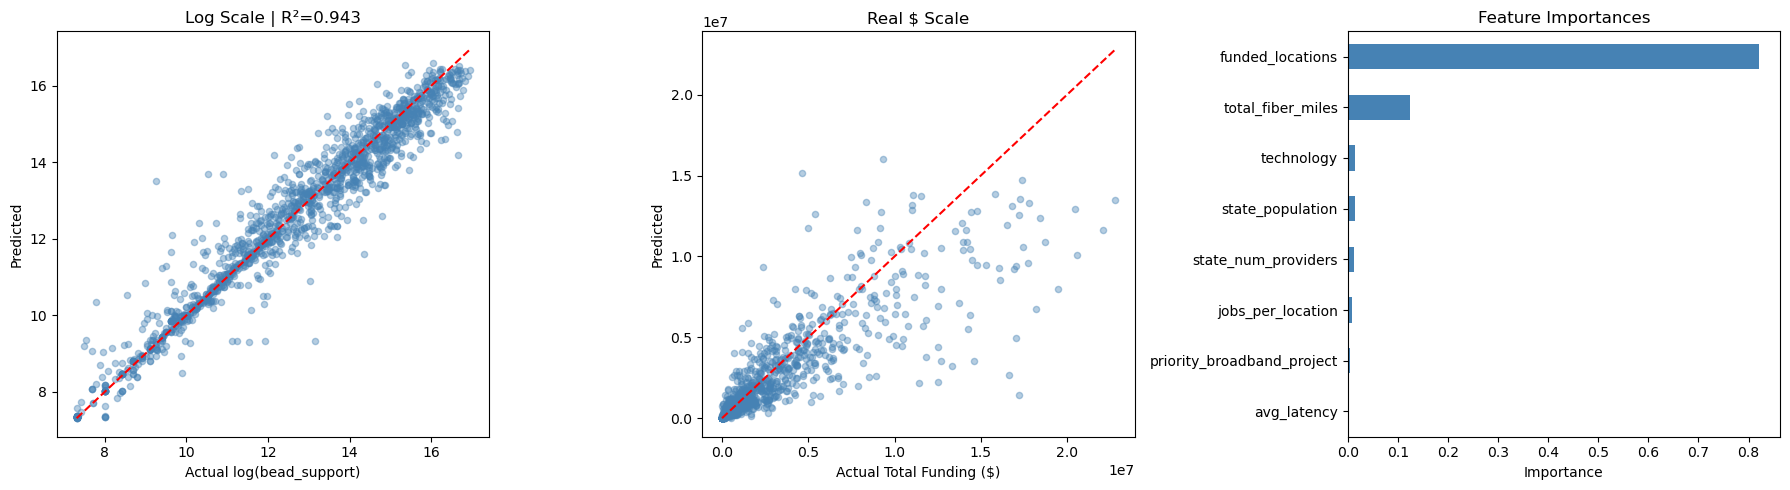

In [6]:
# Predicted vs Actual + Feature Importance
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Log scale
axes[0].scatter(y_test, y_pred, alpha=0.4, s=20, color='steelblue')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--')
axes[0].set_xlabel('Actual log(bead_support)')
axes[0].set_ylabel('Predicted')
axes[0].set_title(f'Log Scale | R²={r2:.3f}')

# Real $ scale
yt_real = np.expm1(y_test)
yp_real = np.expm1(y_pred)
axes[1].scatter(yt_real, yp_real, alpha=0.4, s=20, color='steelblue')
lims2 = [min(yt_real.min(), yp_real.min()), max(yt_real.max(), yp_real.max())]
axes[1].plot(lims2, lims2, 'r--')
axes[1].set_xlabel('Actual Total Funding ($)')
axes[1].set_ylabel('Predicted')
axes[1].set_title('Real $ Scale')

# Feature importance
imp = pd.Series(rf.feature_importances_, index=feature_cols).sort_values()
imp.plot.barh(ax=axes[2], color='steelblue')
axes[2].set_xlabel('Importance')
axes[2].set_title('Feature Importances')

plt.tight_layout()
plt.show()

## SHAP Analysis

In [7]:
try:
    import shap
except ImportError:
    import subprocess
    subprocess.check_call(['pip', 'install', 'shap'])
    import shap
print(f'SHAP version: {shap.__version__}')

SHAP version: 0.52.0


In [8]:
# Compute SHAP values
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)
print(f'SHAP values shape: {shap_values.shape}')

SHAP values shape: (1487, 8)


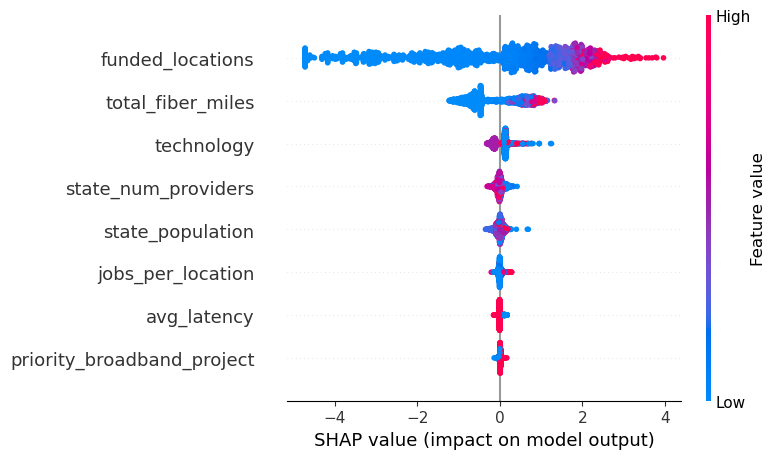

In [9]:
# SHAP summary plot — shows direction + magnitude of each feature's effect
shap.summary_plot(shap_values, X_test, feature_names=feature_cols, show=True)

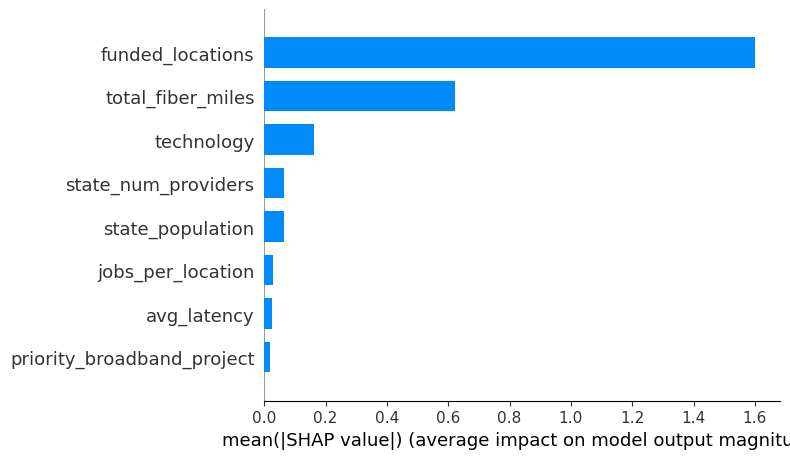

In [10]:
# SHAP bar plot — mean absolute SHAP value per feature
shap.summary_plot(shap_values, X_test, feature_names=feature_cols, plot_type='bar', show=True)

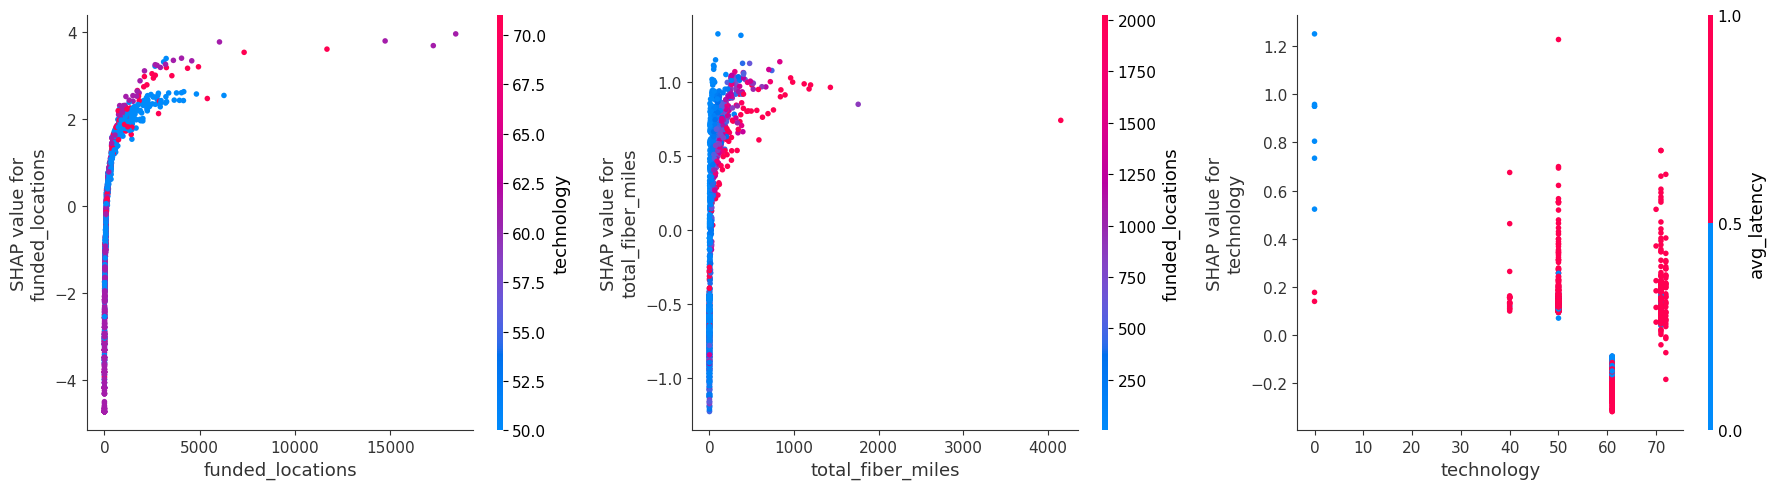

In [11]:
# SHAP dependence plots for top 3 features
top3 = pd.Series(np.abs(shap_values).mean(axis=0), index=feature_cols).nlargest(3).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, feat in enumerate(top3):
    shap.dependence_plot(feat, shap_values, X_test, feature_names=feature_cols, ax=axes[i], show=False)
plt.tight_layout()
plt.show()

=== Highest Funded Project ===
Actual: $22,775,986 total funding
Predicted: $13,476,566 total funding


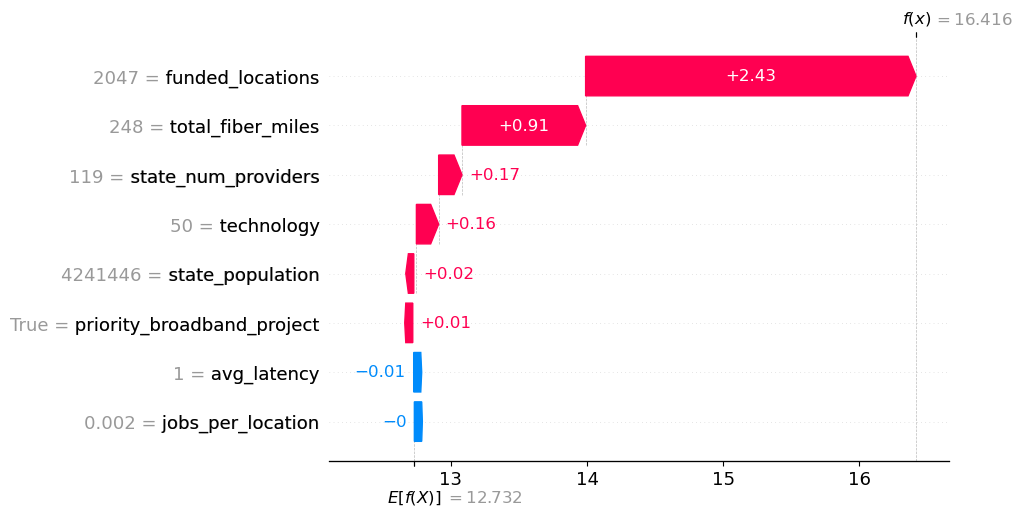


=== Lowest Funded Project ===
Actual: $1,500 total funding
Predicted: $1,559 total funding


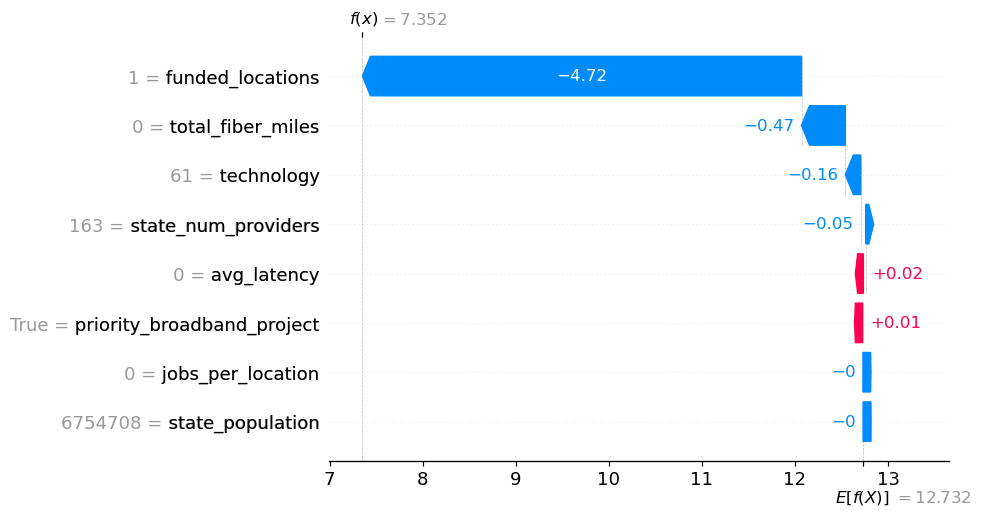

In [12]:
# SHAP waterfall for individual predictions
# Show highest and lowest funded projects
idx_high = y_test.idxmax()
idx_low = y_test.idxmin()

pos_high = list(X_test.index).index(idx_high)
pos_low = list(X_test.index).index(idx_low)

print('=== Highest Funded Project ===')
print(f'Actual: ${np.expm1(y_test.loc[idx_high]):,.0f} total funding')
print(f'Predicted: ${np.expm1(y_pred[pos_high]):,.0f} total funding')
shap.plots.waterfall(shap.Explanation(values=shap_values[pos_high], 
                                       base_values=explainer.expected_value,
                                       data=X_test.iloc[pos_high],
                                       feature_names=feature_cols), show=True)

print('\n=== Lowest Funded Project ===')
print(f'Actual: ${np.expm1(y_test.loc[idx_low]):,.0f} total funding')
print(f'Predicted: ${np.expm1(y_pred[pos_low]):,.0f} total funding')
shap.plots.waterfall(shap.Explanation(values=shap_values[pos_low],
                                       base_values=explainer.expected_value,
                                       data=X_test.iloc[pos_low],
                                       feature_names=feature_cols), show=True)

## LIME Analysis

In [13]:
try:
    import lime
    import lime.lime_tabular
except ImportError:
    import subprocess
    subprocess.check_call(['pip', 'install', 'lime'])
    import lime
    import lime.lime_tabular
print('LIME imported successfully')

LIME imported successfully


In [14]:
# Create LIME explainer
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=feature_cols,
    mode='regression',
    random_state=42
)
print('LIME explainer ready')

LIME explainer ready



=== High Funding ===
Actual: $9,349,697 | Predicted: $16,030,834
Features: {'funded_locations': np.int64(3371), 'technology': np.float64(50.0), 'jobs_per_location': np.float64(0.0017798872738059924), 'state_population': np.int64(4645294), 'total_fiber_miles': np.float64(579.0), 'state_num_providers': np.int64(102), 'avg_latency': np.float64(1.0), 'priority_broadband_project': np.True_}


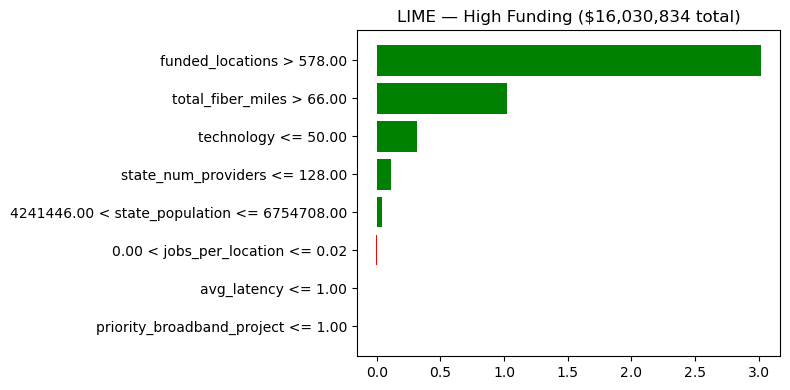

Feature contributions:
  +3.0176  funded_locations > 578.00
  +1.0245  total_fiber_miles > 66.00
  +0.3143  technology <= 50.00
  +0.1100  state_num_providers <= 128.00
  +0.0420  4241446.00 < state_population <= 6754708.00
  -0.0040  0.00 < jobs_per_location <= 0.02
  +0.0000  avg_latency <= 1.00
  +0.0000  priority_broadband_project <= 1.00

=== Median Funding ===
Actual: $297,355 | Predicted: $437,789
Features: {'funded_locations': np.int64(307), 'technology': np.float64(71.0), 'jobs_per_location': np.float64(0.006514657980456026), 'state_population': np.int64(6754708), 'total_fiber_miles': np.float64(0.0), 'state_num_providers': np.int64(163), 'avg_latency': np.float64(1.0), 'priority_broadband_project': np.True_}


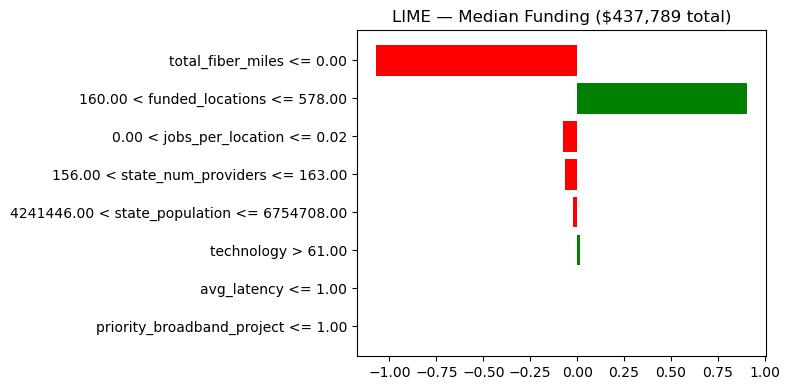

Feature contributions:
  -1.0736  total_fiber_miles <= 0.00
  +0.9053  160.00 < funded_locations <= 578.00
  -0.0767  0.00 < jobs_per_location <= 0.02
  -0.0670  156.00 < state_num_providers <= 163.00
  -0.0197  4241446.00 < state_population <= 6754708.00
  +0.0167  technology > 61.00
  +0.0000  avg_latency <= 1.00
  +0.0000  priority_broadband_project <= 1.00

=== Low Funding ===
Actual: $1,500 | Predicted: $1,507
Features: {'funded_locations': np.int64(2), 'technology': np.float64(61.0), 'jobs_per_location': np.float64(0.0), 'state_population': np.int64(4645294), 'total_fiber_miles': np.float64(0.0), 'state_num_providers': np.int64(102), 'avg_latency': np.float64(1.0), 'priority_broadband_project': np.True_}


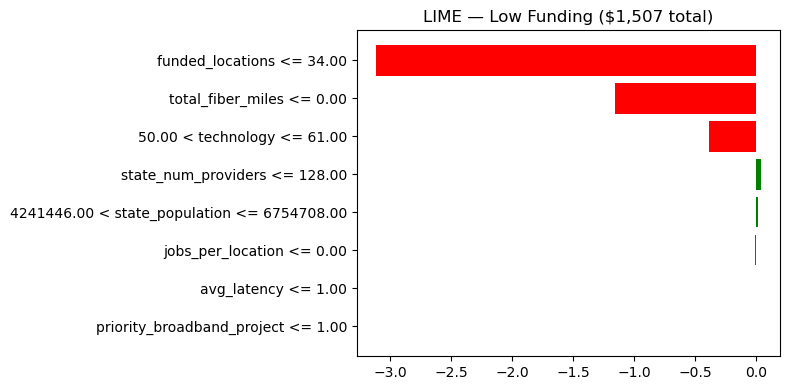

Feature contributions:
  -3.1141  funded_locations <= 34.00
  -1.1539  total_fiber_miles <= 0.00
  -0.3874  50.00 < technology <= 61.00
  +0.0400  state_num_providers <= 128.00
  +0.0162  4241446.00 < state_population <= 6754708.00
  -0.0110  jobs_per_location <= 0.00
  +0.0000  avg_latency <= 1.00
  +0.0000  priority_broadband_project <= 1.00


In [15]:
# LIME explanations for 3 representative projects
# High, median, and low funding predictions
pred_series = pd.Series(y_pred, index=range(len(y_pred)))
idx_high = int(pred_series.idxmax())
idx_med = int(pred_series.sub(pred_series.median()).abs().idxmin())
idx_low = int(pred_series.idxmin())

y_test_arr = y_test.values

for label, pos in [('High Funding', idx_high), ('Median Funding', idx_med), ('Low Funding', idx_low)]:
    actual = np.expm1(y_test_arr[pos])
    predicted = np.expm1(y_pred[pos])
    
    print(f'\n=== {label} ===')
    print(f'Actual: ${actual:,.0f} | Predicted: ${predicted:,.0f}')
    
    row = X_test.iloc[pos].values
    print(f'Features: {dict(zip(feature_cols, row))}')
    
    exp = lime_explainer.explain_instance(row, rf.predict, num_features=len(feature_cols))
    
    fig = exp.as_pyplot_figure()
    fig.set_size_inches(8, 4)
    plt.title(f'LIME — {label} (${predicted:,.0f} total)')
    plt.tight_layout()
    plt.show()
    
    print('Feature contributions:')
    for feat_rule, weight in exp.as_list():
        print(f'  {weight:+.4f}  {feat_rule}')

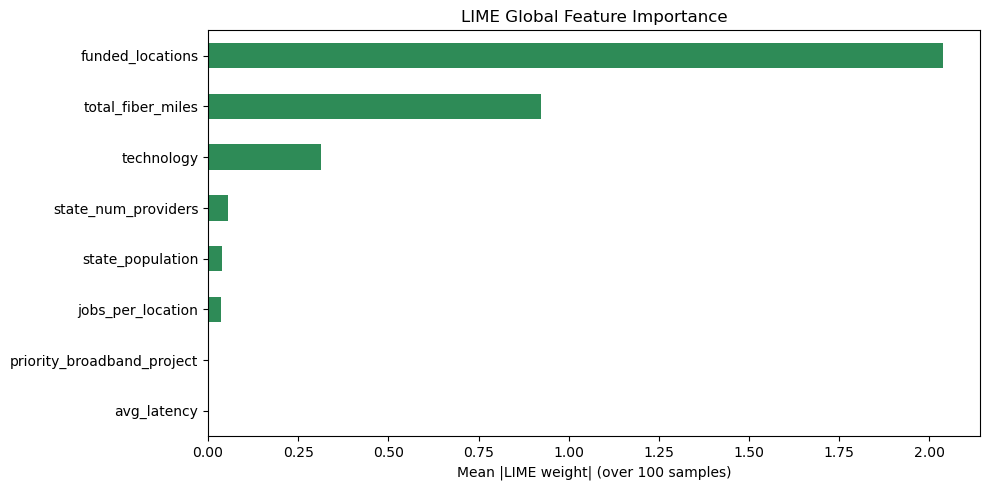

funded_locations              2.038892
total_fiber_miles             0.923551
technology                    0.314245
state_num_providers           0.055649
state_population              0.037578
jobs_per_location             0.035979
avg_latency                   0.000000
priority_broadband_project    0.000000


In [16]:
# LIME global feature importance (average over 100 samples)
n_samples = min(100, len(X_test))
sample_idx = np.random.RandomState(42).choice(len(X_test), n_samples, replace=False)

lime_importances = {feat: [] for feat in feature_cols}
for i in sample_idx:
    exp = lime_explainer.explain_instance(X_test.iloc[i].values, rf.predict, num_features=len(feature_cols))
    for feat_rule, weight in exp.as_list():
        matched = False
        for feat in sorted(feature_cols, key=len, reverse=True):
            if feat in feat_rule:
                lime_importances[feat].append(abs(weight))
                matched = True
                break
        if not matched:
            print(f'Unmatched rule: {feat_rule}')

lime_global = pd.Series({f: np.mean(v) if v else 0 for f, v in lime_importances.items()}).sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
lime_global.plot.barh(ax=ax, color='seagreen')
ax.set_xlabel('Mean |LIME weight| (over 100 samples)')
ax.set_title('LIME Global Feature Importance')
plt.tight_layout()
plt.show()

print(lime_global.sort_values(ascending=False).to_string())

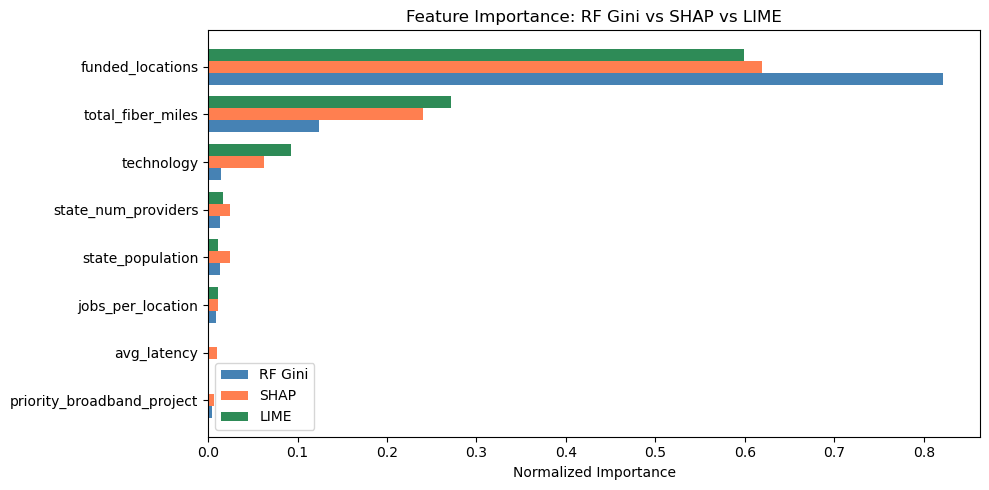

                            RF Gini   SHAP   LIME
priority_broadband_project    0.004  0.007  0.000
avg_latency                   0.001  0.010  0.000
jobs_per_location             0.009  0.011  0.011
state_population              0.014  0.025  0.011
state_num_providers           0.013  0.025  0.016
technology                    0.014  0.063  0.092
total_fiber_miles             0.124  0.240  0.271
funded_locations              0.822  0.619  0.599


In [17]:
# Side-by-side: RF Gini vs SHAP vs LIME importance
shap_global = pd.Series(np.abs(shap_values).mean(axis=0), index=feature_cols)
rf_global = pd.Series(rf.feature_importances_, index=feature_cols)

comp = pd.DataFrame({
    'RF Gini': rf_global / rf_global.sum(),
    'SHAP': shap_global / shap_global.sum(),
    'LIME': lime_global / lime_global.sum(),
}).sort_values('SHAP', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(comp))
w = 0.25
ax.barh(x - w, comp['RF Gini'], w, label='RF Gini', color='steelblue')
ax.barh(x, comp['SHAP'], w, label='SHAP', color='coral')
ax.barh(x + w, comp['LIME'], w, label='LIME', color='seagreen')
ax.set_yticks(x)
ax.set_yticklabels(comp.index)
ax.set_xlabel('Normalized Importance')
ax.set_title('Feature Importance: RF Gini vs SHAP vs LIME')
ax.legend()
plt.tight_layout()
plt.show()

print(comp.round(3).to_string())